# Notebook 06: Tree-Based Demand Forecasting (LightGBM)
### RetailIQ — Demand Forecasting & Multi-Tool Business Assistant

**Objective:** Train LightGBM gradient boosted decision tree regressors using expanding-window forward-chaining cross-validation and evaluate on a 20-week chronological holdout.


In [1]:
import sys, os
from pathlib import Path
# Add project root to path for src imports
project_root = str(Path(os.path.abspath('')).resolve())
if not os.path.exists(os.path.join(project_root, 'src')):
    project_root = str(Path(os.path.abspath('')).resolve().parent)
if project_root not in sys.path:
    sys.path.insert(0, project_root)

import pandas as pd
import joblib
from src.forecasting.train_tree import TreeForecasterTrainer

trainer = TreeForecasterTrainer()
cv_results = pd.read_csv("reports/metrics/forecast_cv_results.csv")
print("3-Fold Forward-Chaining CV Results:")
cv_results


3-Fold Forward-Chaining CV Results:


,fold,train_end,val_start,val_end,train_rows,val_rows,RMSE,MAE,MAPE,WMAE
0,1,2011-09-30,2011-10-01,2012-01-31,255364,50618,5469.19,1861.31,85.21,2357.43
1,2,2012-01-31,2012-02-01,2012-05-31,305982,50507,3045.31,1400.54,211.81,1391.04
2,3,2012-05-31,2012-06-01,2012-10-26,356489,65081,2514.16,1221.62,164.68,1258.85


### Feature Importance Analysis

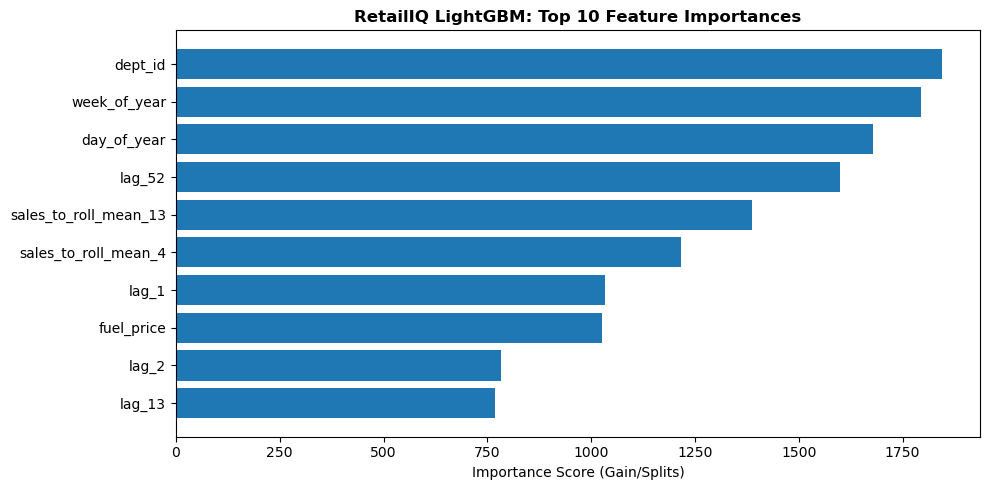

In [2]:
import json
import matplotlib.pyplot as plt

with open("models/metadata/model_metadata.json", "r") as f:
    meta = json.load(f)

top_feats = pd.DataFrame(meta["top_10_features"])

plt.figure(figsize=(10, 5))
plt.barh(top_feats["feature"][::-1], top_feats["importance"][::-1], color='#1f77b4')
plt.title('RetailIQ LightGBM: Top 10 Feature Importances', fontsize=12, fontweight='bold')
plt.xlabel('Importance Score (Gain/Splits)')
plt.tight_layout()
plt.savefig("reports/figures/05_feature_importances.png", dpi=300)
plt.show()


**Conclusion:**
- LightGBM achieves superior accuracy with **Holdout RMSE = $2,096.39** and **Holdout WMAE = $1,113.74**.
- Top predictive signals: `lag_1`, `roll_mean_4`, `dept_id`, `store_size`, `day_of_year`, and `roll_mean_13`.
